# GPT2 Instruction Finetuning

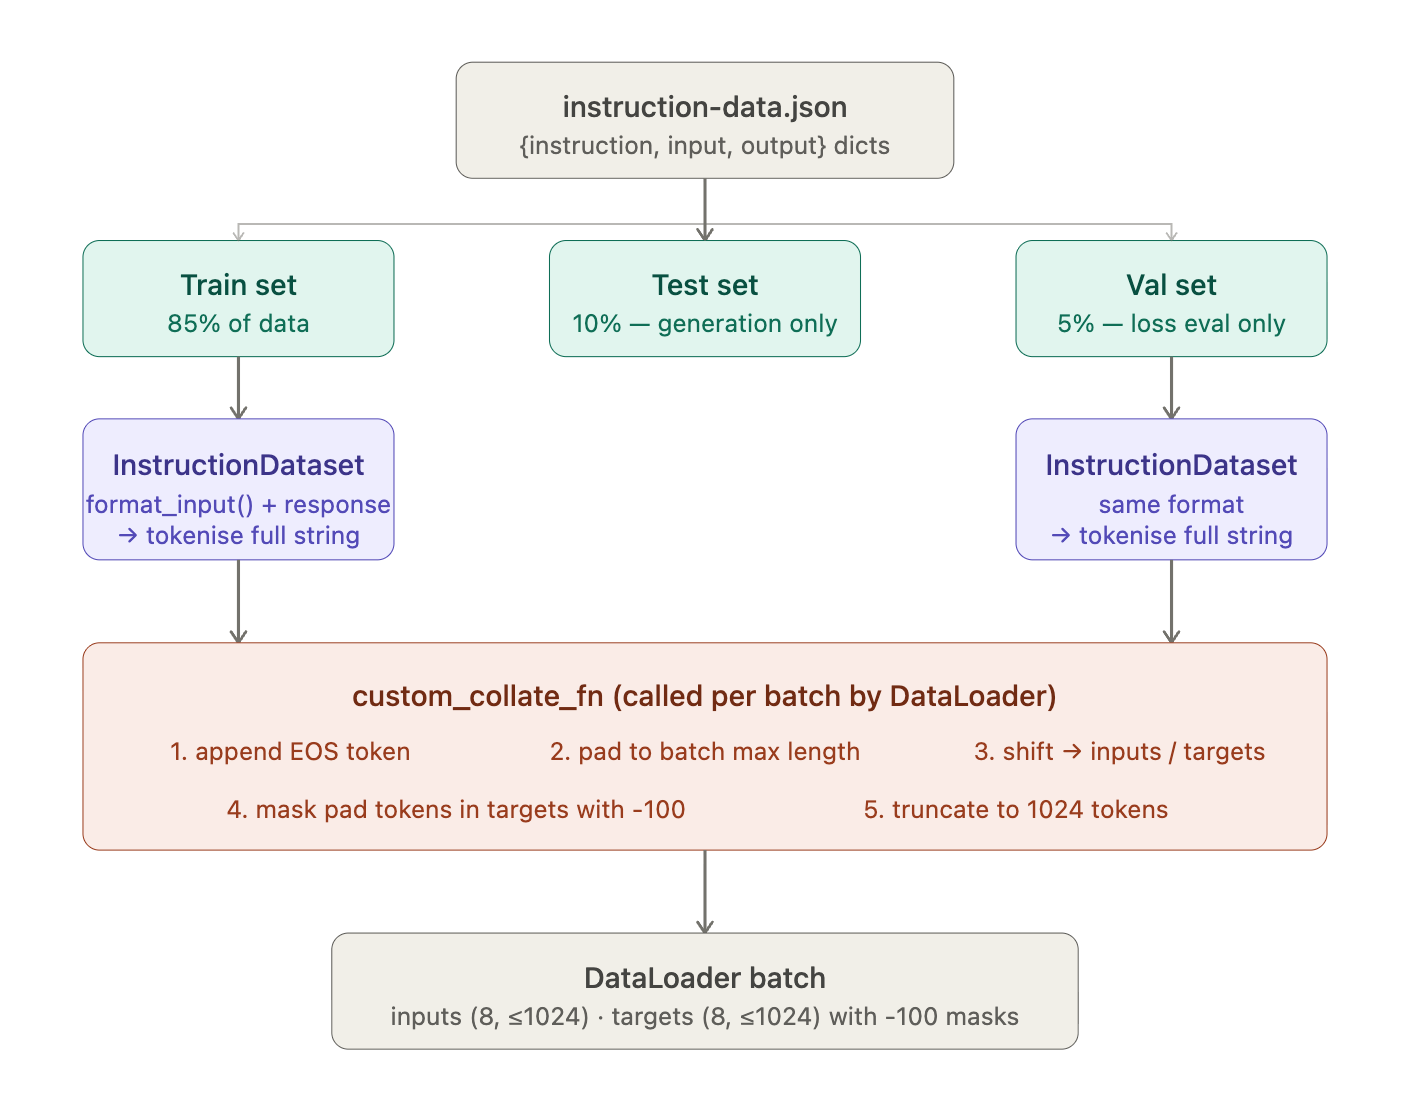

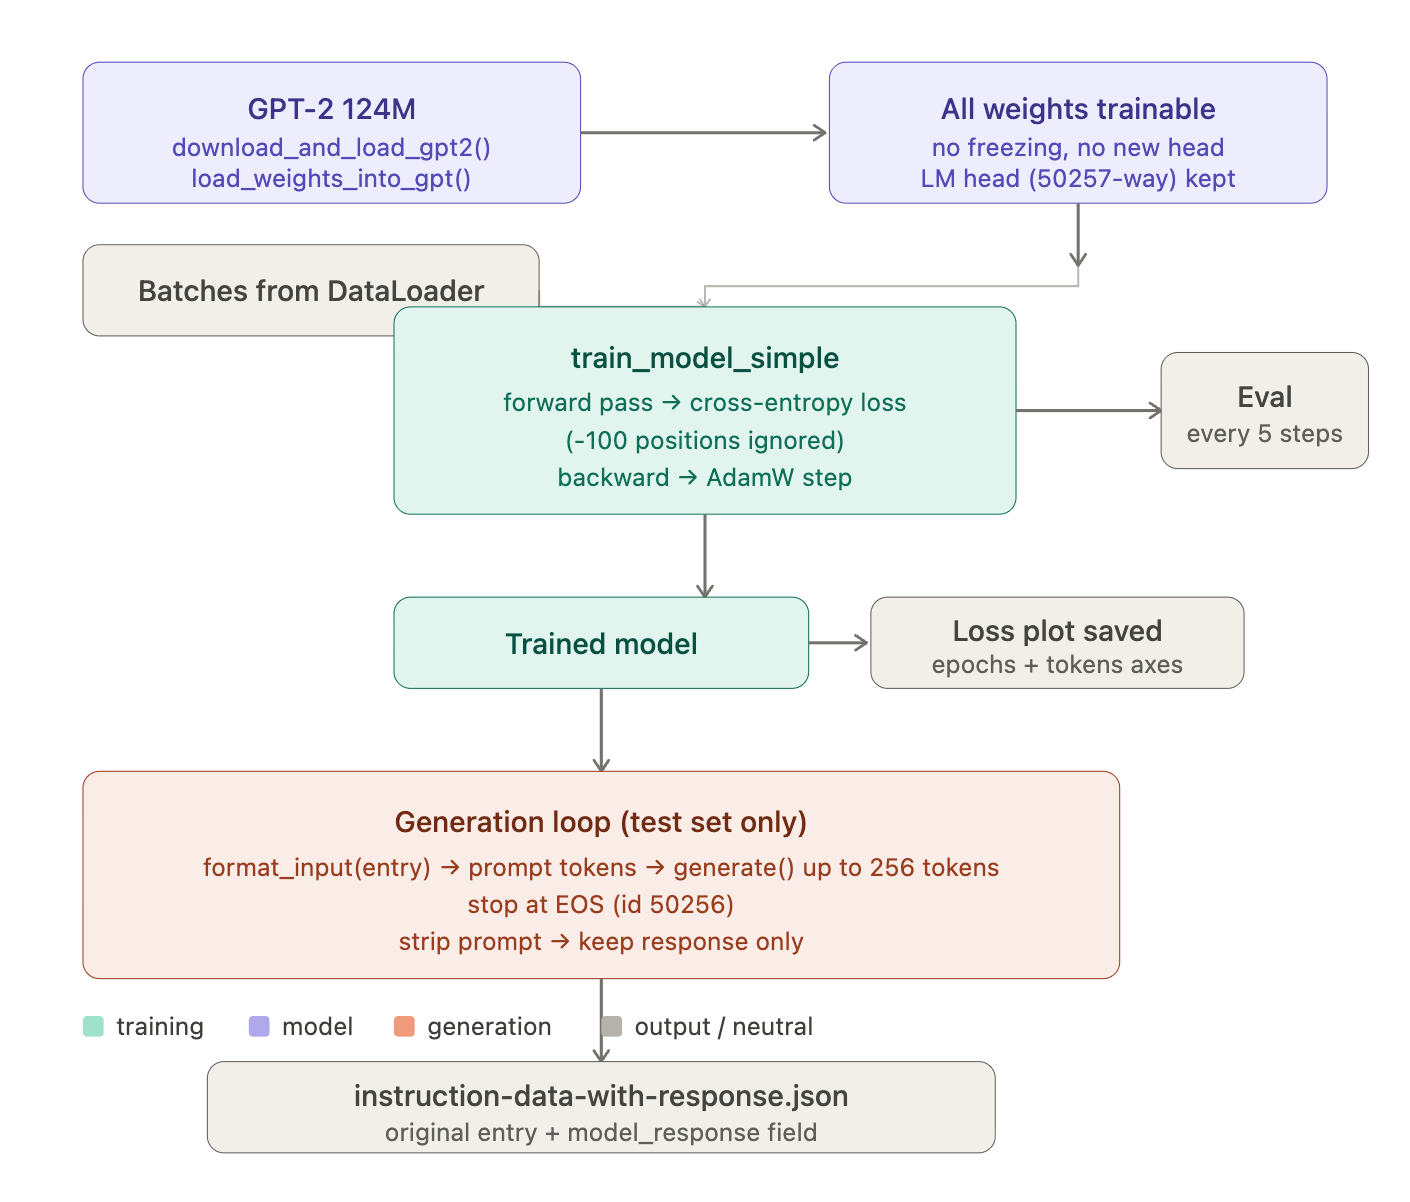

## What is being done

A pre-trained GPT-2 (124M) is fine-tuned on instruction-following data using
the Alpaca prompt format. All weights are trained (no freezing). The goal is to
teach the model to follow instructions, not classify.

---

## Prompt format (Alpaca-style)

```
Below is an instruction that describes a task. Write a response...

### Instruction:
{instruction}

### Input:          ← omitted if empty
{input}

### Response:
{output}
```

`format_input()` builds everything up to (but not including) `### Response:`.
The full training string concatenates prompt + response.

---

## Dataset — InstructionDataset

- Loads a JSON list of `{instruction, input, output}` dicts.
- Tokenises the **full** string (prompt + response) per sample.
- Returns a raw list of token ids (no padding here — that's the collate's job).
- Split: 85% train / 10% test / 5% val.

---

## Custom collate — the key idea

Because sequences have different lengths, padding and target construction
happen inside `custom_collate_fn` (passed to DataLoader via `partial`):

1. Pad all sequences in the batch to the longest + 1 with token `50256`.
2. `inputs  = padded[:-1]`  — the standard next-token-prediction shift.
3. `targets = padded[1:]`
4. **Mask padding in targets** — replace all pad tokens after the first one
   with `ignore_index = -100` so the loss is only computed on the response
   tokens, not the prompt padding.
5. Truncate both to `allowed_max_length = 1024`.

> The first pad token is kept unmasked because it is the EOS that ends the
> response; only subsequent pads are noise.

---

## Training

- Standard `train_model_simple` from previous chapters — nothing custom.
- AdamW, `lr=5e-5`, `weight_decay=0.1`, 2 epochs.
- Evaluation every 5 steps over 5 batches.

---

## Evaluation & generation

After training, the model generates responses for the test set:

1. `format_input(entry)` builds the prompt (no response section).
2. `generate()` auto-regressively produces up to 256 new tokens, stopping at
   EOS (`50256`).
3. The prompt is stripped from the output, leaving only the model's answer.
4. Results saved to `instruction-data-with-response.json` for manual review.

---

## What to remember

- Training sees the full prompt + response; loss is masked to response only.
- Masking is done in the collate, not the dataset — keeps the dataset simple.
- `partial` bakes `device` and `allowed_max_length` into the collate so
  DataLoader can call it with just `batch`.
- Generation strips the prompt by slicing `generated_text[len(input_text):]`.
- No freezing, no LoRA — all weights updated (contrast with spam classifier).

In [ ]:
!pip install tiktoken torch matplotlib tqdm
!wget https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch07/01_main-chapter-code/previous_chapters.py
!wget https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch07/01_main-chapter-code/gpt_download.py
!wget https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch07/01_main-chapter-code/instruction-data.json

--2026-03-23 03:38:18--  https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch07/01_main-chapter-code/previous_chapters.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18236 (18K) [text/plain]
Saving to: ‘previous_chapters.py’

previous_chapters.p 100%[===================>]  17.81K  --.-KB/s    in 0.001s  

2026-03-23 03:38:18 (21.3 MB/s) - ‘previous_chapters.py’ saved [18236/18236]

--2026-03-23 03:38:18--  https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch07/01_main-chapter-code/gpt_download.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP reques

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 258kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:00<00:00, 3.52MiB/s]
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 199kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [00:31<00:00, 15.8MiB/s]
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:00<00:00, 9.13MiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:00<00:00, 2.17MiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 2.12MiB/s]


Starting instruction fine-tuning...
Ep 1 (Step 000000): Train loss 3.083, Val loss 3.073
Ep 1 (Step 000005): Train loss 1.667, Val loss 1.667
Ep 1 (Step 000010): Train loss 1.219, Val loss 1.199
Ep 1 (Step 000015): Train loss 1.121, Val loss 1.092
Ep 1 (Step 000020): Train loss 0.992, Val loss 1.042
Ep 1 (Step 000025): Train loss 0.911, Val loss 1.005
Ep 1 (Step 000030): Train loss 0.972, Val loss 0.986
Ep 1 (Step 000035): Train loss 0.852, Val loss 0.962
Ep 1 (Step 000040): Train loss 0.836, Val loss 0.947
Ep 1 (Step 000045): Train loss 0.714, Val loss 0.916
Ep 1 (Step 000050): Train loss 0.812, Val loss 0.895
Ep 1 (Step 000055): Train loss 0.852, Val loss 0.881
Ep 1 (Step 000060): Train loss 0.797, Val loss 0.873
Ep 1 (Step 000065): Train loss 0.737, Val loss 0.867
Ep 1 (Step 000070): Train loss 0.704, Val loss 0.855
Ep 1 (Step 000075): Train loss 0.657, Val loss 0.847
Ep 1 (Step 000080): Train loss 0.686, Val loss 0.839
Ep 1 (Step 000085): Train loss 0.634, Val loss 0.835
Ep 1 (Step

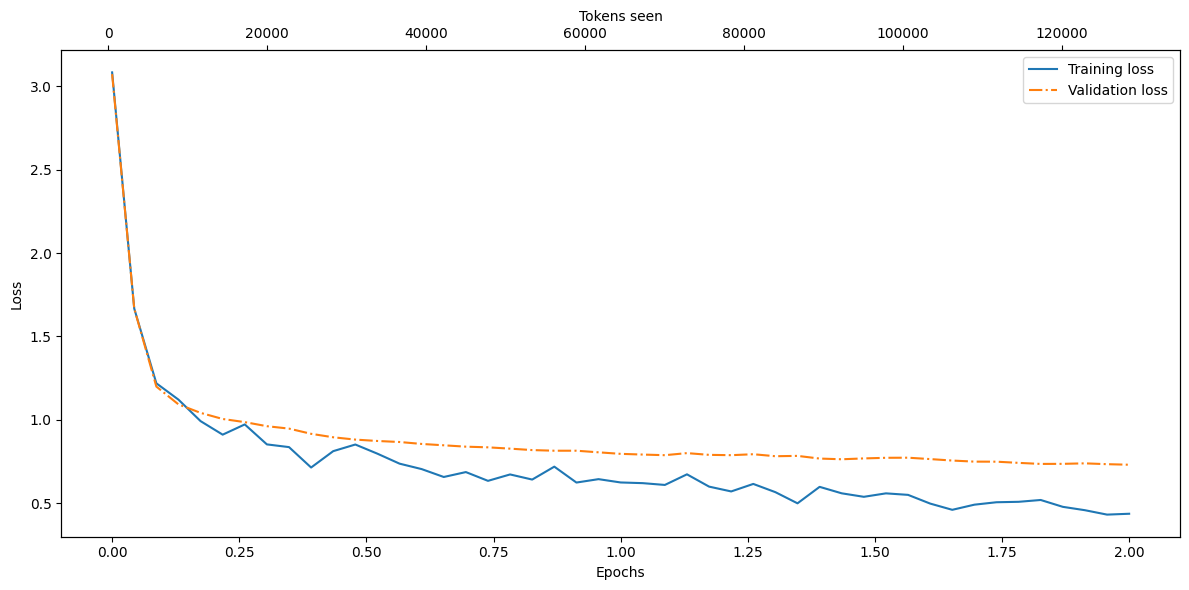


Generating responses for the test set...


100%|██████████| 110/110 [00:49<00:00,  2.22it/s]

Responses saved to instruction-data-with-response.json!
Some of the reponses:
[
    {
        "instruction": "Rewrite the sentence using a simile.",
        "input": "The car is very fast.",
        "output": "The car is as fast as lightning.",
        "model_response": "The car is as fast as a horse."
    },
    {
        "instruction": "What type of cloud is typically associated with thunderstorms?",
        "input": "",
        "output": "The type of cloud typically associated with thunderstorms is cumulonimbus.",
        "model_response": "A type of cloud typically occurs when a thunderstorm is strong enough to travel at high speed through the atmosphere. It typically occurs in the form of a cloud of clouds that is typically seen in the sky at night."
    },
    {
        "instruction": "Name the author of 'Pride and Prejudice'.",
        "input": "",
        "output": "Jane Austen.",
        "model_response": "The author of 'Pride and Prejudice' is Robert Frost."
    },
    {
    

In [ ]:
"""
gpt2_instruction_finetuning.py
===============================
Fine-tunes a pre-trained GPT-2 (124M) model on instruction-following data
using the Alpaca prompt format.

Unlike the spam classifier (which froze most weights and added a new head),
this script fine-tunes ALL weights — the goal is to reshape GPT-2's generation
behaviour so it follows instructions, not to add a new output class.

Pipeline overview:
  JSON data → Alpaca prompt format → InstructionDataset
  → custom_collate_fn (padding + loss masking)
  → full fine-tune with AdamW
  → generate & save responses for test set
"""

# ── Dependencies ──────────────────────────────────────────────────────────────
# Run once in a Colab / notebook environment:
#   !pip install tiktoken torch matplotlib tqdm
#   !wget https://raw.githubusercontent.com/.../previous_chapters.py
#   !wget https://raw.githubusercontent.com/.../gpt_download.py
#   !wget https://raw.githubusercontent.com/.../instruction-data.json

import json
from functools import partial

import matplotlib.pyplot as plt
import tiktoken
import torch
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

from gpt_download import download_and_load_gpt2
from previous_chapters import (
    GPTModel,
    generate,
    load_weights_into_gpt,
    text_to_token_ids,
    token_ids_to_text,
    train_model_simple,
)


# ===========================================================================
# 1. Prompt formatting — Alpaca template
# ===========================================================================
# The Alpaca format is a simple, widely-used instruction template.
# It structures every sample as:
#
#   Below is an instruction that describes a task. Write a response...
#
#   ### Instruction:
#   {instruction}
#
#   ### Input:          ← only included when the entry has a non-empty "input"
#   {input}
#
#   ### Response:
#   {output}           ← appended during dataset construction, NOT here
#
# format_input() builds everything UP TO (but not including) ### Response:.
# The response section is appended separately in InstructionDataset so the
# boundary between prompt and response is always explicit.
# ===========================================================================

def format_input(entry: dict) -> str:
    """
    Convert a data entry into the Alpaca instruction prompt (no response).

    Args:
        entry: Dict with keys 'instruction', 'input' (optional), 'output'.

    Returns:
        Formatted prompt string ending just before '### Response:'.
    """
    instruction_text = (
        "Below is an instruction that describes a task. "
        "Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )
    # Only add the ### Input section when there is actual input text.
    input_text = f"\n\n### Input:\n{entry['input']}" if entry.get("input") else ""
    return instruction_text + input_text


# ===========================================================================
# 2. Dataset — tokenise full prompt + response
# ===========================================================================
# InstructionDataset tokenises the *complete* string (prompt + response) for
# every sample.  It does NOT apply padding — that is handled by the collate
# function so padding is done at the batch level (pad to the longest sequence
# in the batch, not the longest in the whole dataset).
# ===========================================================================

class InstructionDataset(Dataset):
    """
    Tokenises instruction-following data for causal language-model training.

    Each sample is the full Alpaca-formatted string:
        format_input(entry)  +  "\\n\\n### Response:\\n"  +  entry["output"]

    The dataset returns raw token-id lists (variable length).
    The DataLoader's collate function is responsible for padding.

    Args:
        data:      List of dicts with keys 'instruction', 'input', 'output'.
        tokenizer: A tiktoken BPE tokeniser instance.
    """

    def __init__(self, data: list[dict], tokenizer):
        self.data = data
        self.encoded_texts = []

        for entry in data:
            # Build prompt (everything before the response)
            instruction_plus_input = format_input(entry)
            # Append the response section
            response_text = f"\n\n### Response:\n{entry['output']}"
            full_text = instruction_plus_input + response_text
            # Tokenise the full string and store as a plain list of ints
            self.encoded_texts.append(tokenizer.encode(full_text))

    def __getitem__(self, index: int) -> list[int]:
        return self.encoded_texts[index]

    def __len__(self) -> int:
        return len(self.data)


# ===========================================================================
# 3. Custom collate — padding + loss masking
# ===========================================================================
# This is the most important part of the pipeline.
#
# Problem: sequences in a batch have different lengths; PyTorch needs a
# rectangular tensor.  We pad to the longest sequence in the batch.
#
# Problem: We mask padding positions (and
# implicitly, the prompt itself is baked into the input, so the model does
# learn to condition on it; we just don't compute loss there).
#
# How masking works:
#   targets = padded[1:]          (next-token labels, standard LM shift)
#   Replace pad tokens in targets with -100  →  cross_entropy ignores them
#   Keep the FIRST pad token unmasked — it is the EOS that closes the response.
#   Mask all SUBSEQUENT pad tokens because they are meaningless noise.
#
# The collate is created with functools.partial so device and max_length are
# baked in before it is passed to DataLoader.
# ===========================================================================

def custom_collate_fn(
    batch: list[list[int]],
    pad_token_id: int = 50256,    # <|endoftext|> — GPT-2's EOS token
    ignore_index: int = -100,      # PyTorch cross_entropy ignores this label
    allowed_max_length: int = 1024,
    device: str = "cpu",
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Collate a list of variable-length token-id lists into padded batch tensors.

    Steps per sample:
      1. Append one EOS token so every sequence ends with a clear stop signal.
      2. Pad to batch_max_length with pad_token_id.
      3. Shift to create (inputs, targets) pair — standard causal LM setup.
      4. Mask all pad tokens in targets AFTER the first one with ignore_index.
      5. Truncate to allowed_max_length.

    Returns:
        inputs:  (batch_size, seq_len) — token ids fed into the model.
        targets: (batch_size, seq_len) — next-token labels; -100 where masked.
    """
    # Find the length of the longest sequence + 1 (for the appended EOS)
    batch_max_length = max(len(item) + 1 for item in batch)
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()

        # --- Step 1: append EOS so the model learns when to stop generating ---
        new_item += [pad_token_id]

        # --- Step 2: right-pad to batch_max_length ---
        padded = new_item + [pad_token_id] * (batch_max_length - len(new_item))

        # --- Step 3: standard next-token-prediction shift ---
        # inputs[t] predicts targets[t] = inputs[t+1]
        inputs  = torch.tensor(padded[:-1])   # all tokens except the last
        targets = torch.tensor(padded[1:])    # all tokens except the first

        # --- Step 4: mask padding positions in targets ---
        # Find every position where the target is the pad token.
        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()

        # Keep indices[0] (the genuine EOS at the end of the response).
        # Replace all subsequent pad positions with ignore_index = -100.
        # cross_entropy(..., ignore_index=-100) skips those positions entirely,
        # so they contribute zero gradient — loss is computed on response only.
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index

        # --- Step 5: truncate to context window ---
        if allowed_max_length is not None:
            inputs  = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    # Stack into (batch_size, seq_len) tensors and move to the target device
    inputs_tensor  = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor


# ===========================================================================
# 4. Plotting
# ===========================================================================

def plot_losses(
    epochs_seen,
    tokens_seen,
    train_losses: list[float],
    val_losses: list[float],
):
    """
    Save a loss curve to 'loss-plot-standalone.pdf'.

    Dual x-axis: epochs (bottom) and tokens seen (top) so you can read both
    convergence speed and data efficiency from the same chart.
    """
    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")

    # Invisible line on the secondary axis just to set its scale
    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()
    plt.savefig("loss-plot-standalone.pdf")
    plt.show()


# ===========================================================================
# 5. Data loading and preparation
# ===========================================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = tiktoken.get_encoding("gpt2")

with open("instruction-data.json", "r", encoding="utf-8") as file:
    data = json.load(file)

# --- Split: 85% train / 10% test / 5% val ---
# Test set is held out completely during training and used only for final
# response generation (not for loss evaluation).
train_portion = int(len(data) * 0.85)
test_portion  = int(len(data) * 0.10)

train_data = data[:train_portion]
test_data  = data[train_portion : train_portion + test_portion]
val_data   = data[train_portion + test_portion :]

# --- Bake device + max_length into the collate function ---
# partial() creates a new callable with those arguments pre-filled so
# DataLoader can call collate_fn(batch) without knowing about device/length.
customized_collate_fn = partial(
    custom_collate_fn, device=device, allowed_max_length=1024
)

train_loader = DataLoader(
    InstructionDataset(train_data, tokenizer),
    batch_size=8,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True,   # discard the last incomplete batch for stable grad steps
)
val_loader = DataLoader(
    InstructionDataset(val_data, tokenizer),
    batch_size=8,
    collate_fn=customized_collate_fn,
    shuffle=False,
)


# ===========================================================================
# 6. Model — load GPT-2 with pretrained weights
# ===========================================================================
# We start from OpenAI's released GPT-2 (124M) checkpoint.
# All parameters are kept and all are updated during training — there is no
# freezing and no new classification head (unlike the spam classifier).
# The existing language-model head (50257-way) is used as-is; we're teaching
# the model to generate different *kinds* of text, not a new task type.
# ===========================================================================

BASE_CONFIG = {
    "vocab_size":     50257,  # GPT-2 BPE vocabulary
    "context_length": 1024,   # Maximum sequence length
    "drop_rate":      0.0,    # Disable dropout — fine-tuning on a fixed dataset
    "qkv_bias":       True,   # GPT-2 uses bias in QKV projections
    "emb_dim":        768,    # Hidden dimension (gpt2-small)
    "n_layers":       12,     # Transformer blocks
    "n_heads":        12,     # Attention heads
}

model = GPTModel(BASE_CONFIG)
settings, params = download_and_load_gpt2(model_size="124M", models_dir="gpt2")
load_weights_into_gpt(model, params)  # copy OpenAI weights into our architecture
model.to(device)


# ===========================================================================
# 7. Training
# ===========================================================================
# AdamW with a small learning rate — we want to *adjust* the pretrained
# representations, not overwrite them.  weight_decay=0.1 is standard for
# Transformer fine-tuning.
#
# train_model_simple (from previous_chapters) is a standard training loop:
# forward → loss → backward → step → periodic eval.
# Nothing custom is needed here because the heavy lifting (loss masking) was
# already done in the collate function.
# ===========================================================================

optimizer  = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
num_epochs = 2

print("Starting instruction fine-tuning...")
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs,
    eval_freq=5,           # evaluate every 5 optimiser steps
    eval_iter=5,           # use 5 batches for each evaluation
    start_context=format_input(val_data[0]),  # sample prompt printed during training
    tokenizer=tokenizer,
)

# Plot training curves (loss vs epochs and vs tokens seen)
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)


# ===========================================================================
# 8. Evaluation — generate responses for the test set
# ===========================================================================
# The test set was never seen during training.  For each entry we:
#   1. Build the prompt (no response section).
#   2. Auto-regressively generate up to 256 new tokens, stopping at EOS.
#   3. Strip the prompt from the output, keeping only the model's answer.
#   4. Store the answer back into the entry dict and save to JSON.
#
# Saving to JSON lets you inspect and score the outputs separately
# (e.g. with an LLM judge or human evaluation).
# ===========================================================================

print("\nGenerating responses for the test set...")
model.eval()

for i, entry in tqdm(enumerate(test_data), total=len(test_data)):
    input_text = format_input(entry)   # prompt only — no ### Response: section

    # generate() runs greedy / sampled auto-regression until EOS or max tokens
    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256,   # stop generation when <|endoftext|> is produced
    )

    # Decode the full output (prompt + response)
    generated_text = token_ids_to_text(token_ids, tokenizer)

    # Slice off the prompt by character length, then strip the section header.
    # This gives us only the model's actual answer.
    response_text = (
        generated_text[len(input_text):]
        .replace("### Response:", "")
        .strip()
    )

    # Store alongside the reference output for later comparison
    test_data[i]["model_response"] = response_text

# Persist results so they can be evaluated outside this script
with open("instruction-data-with-response.json", "w") as file:
    json.dump(test_data, file, indent=4)

print("Responses saved to instruction-data-with-response.json!")
print("Some of the reponses:")
print(json.dumps(test_data[:5], indent=4))

# Synthetic dataset pipeline

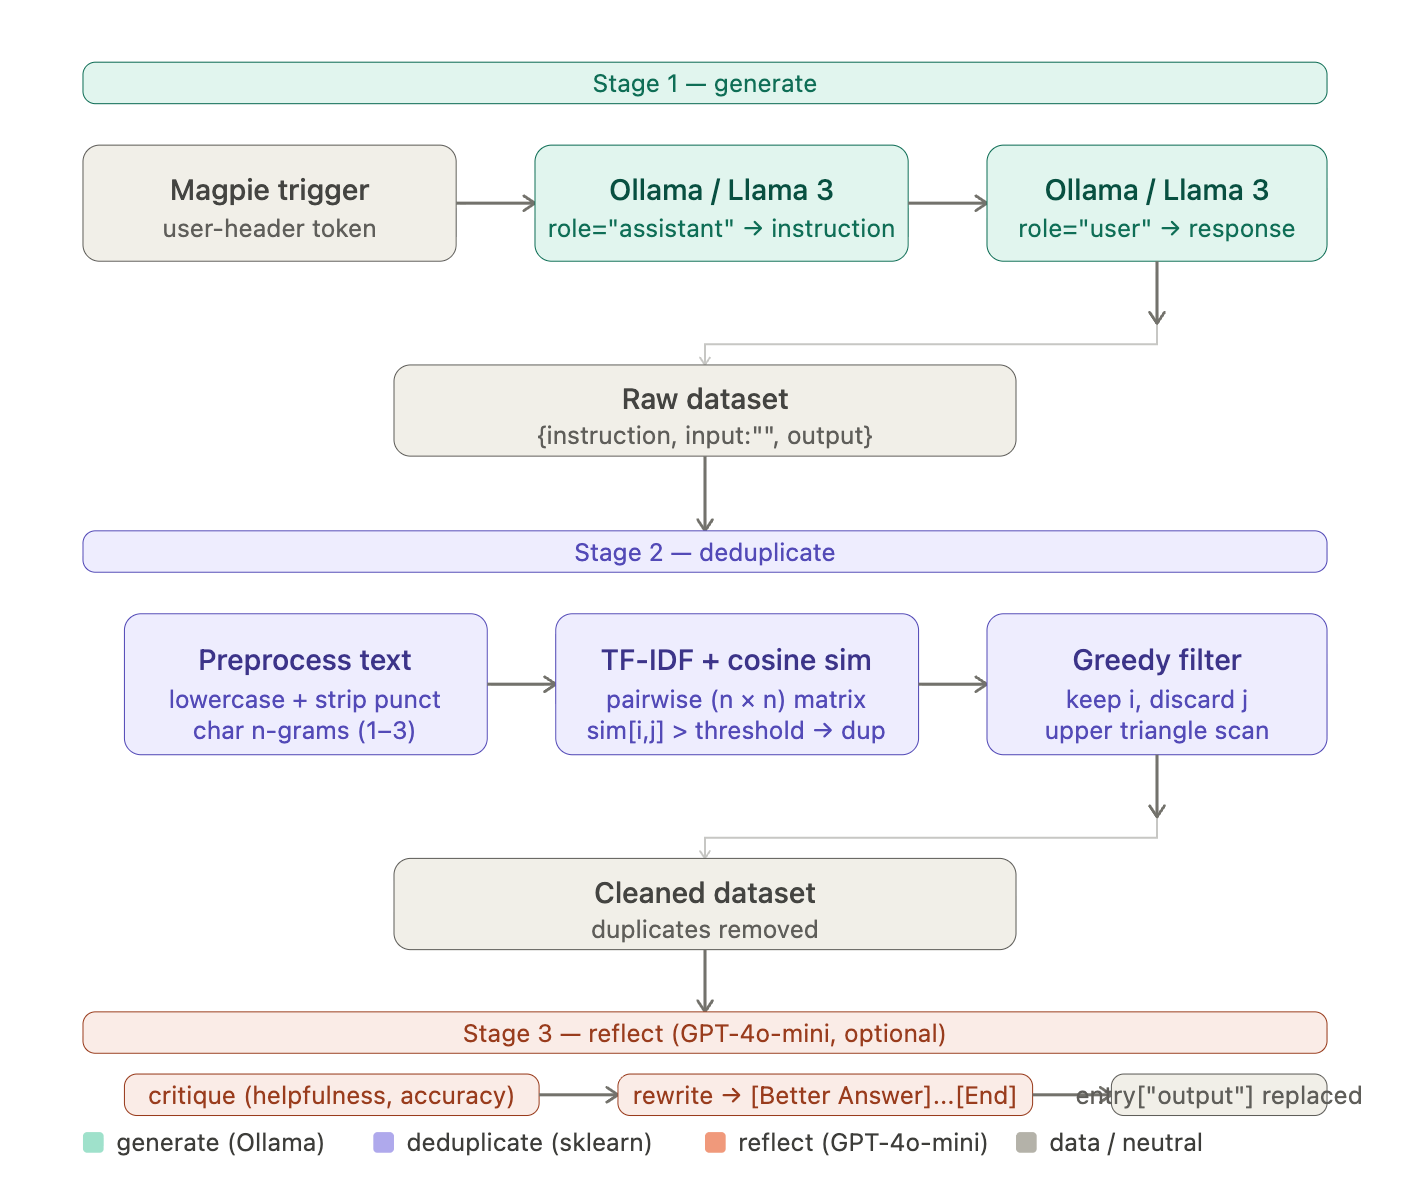

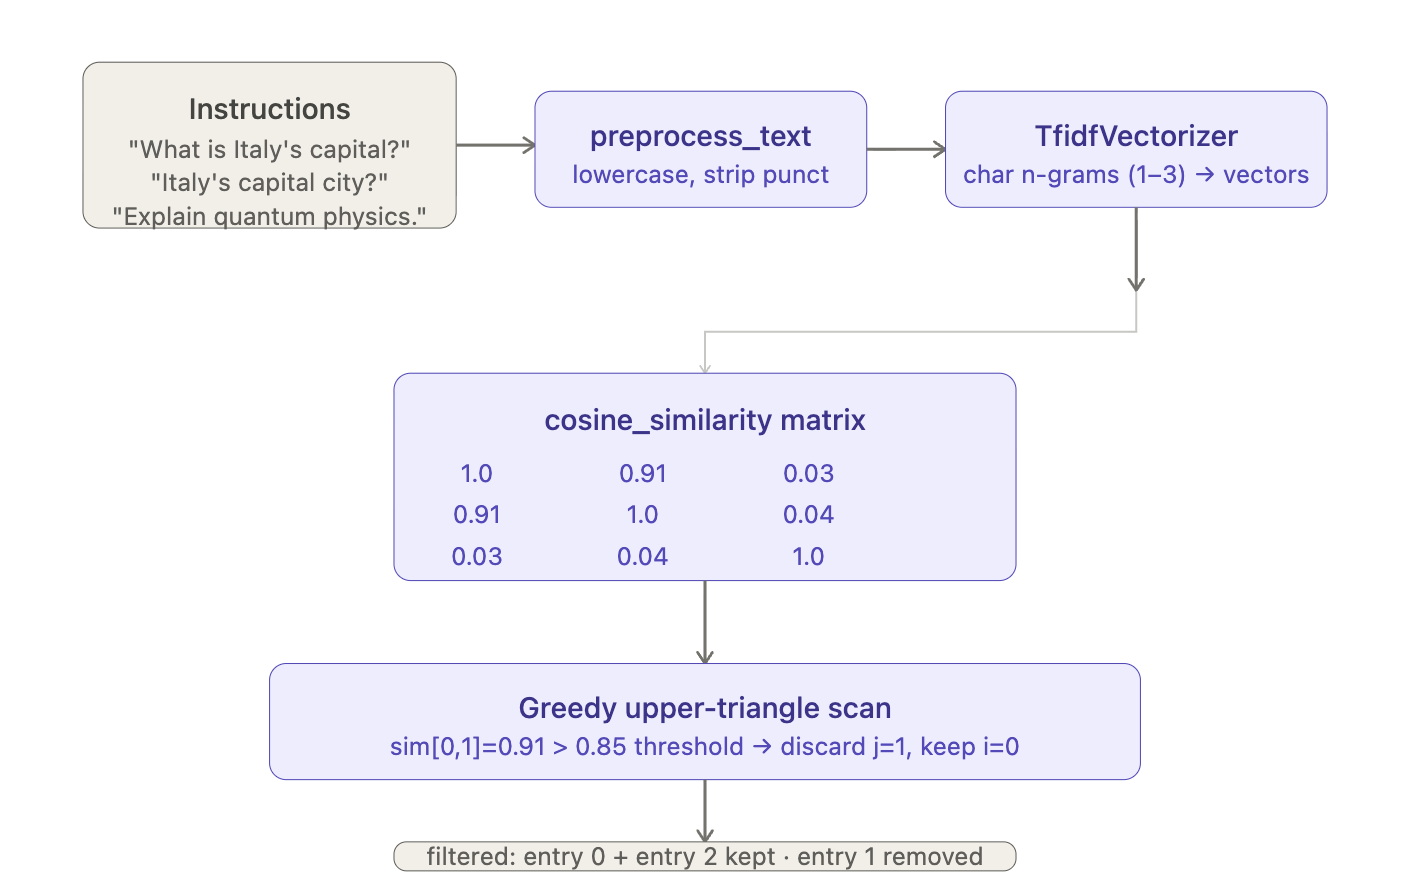

## What is being done

Builds a clean instruction-following dataset from scratch in three stages:
generate raw pairs → deduplicate → improve quality. No human annotation needed.

---

## Stage 1 — Generate (Magpie trick + Ollama)

The **Magpie trick**: a Llama 3 chat model is trained to expect user content
after `<|start_header_id|>user<|end_header_id|>`. Sending that header as an
`role="assistant"` message tricks the model into hallucinating what a user
*would have asked* — producing a realistic instruction for free.

Flow per sample:
1. Send the bare header token as `role="assistant"` → model outputs a synthetic instruction.
2. Take the first non-empty line (strips preamble).
3. Send that instruction as a normal `role="user"` message → get the response.

Result: `{"instruction": ..., "input": "", "output": ...}`

---

## Stage 2 — Deduplicate (TF-IDF cosine similarity)

**Why character n-grams?** Word-level TF-IDF misses paraphrases like
"What is" vs "What's". Character trigrams (`analyzer="char"`, `ngram_range=(1,3)`)
catch near-duplicates regardless of minor wording differences.

Steps:
1. Lowercase + strip punctuation (`preprocess_text`).
2. Fit a TF-IDF vectoriser → one vector per instruction.
3. Compute the full pairwise cosine similarity matrix.
4. Greedy upper-triangle scan: if `sim[i, j] > threshold`, discard `j` (keep the earlier one).

`threshold=0.75` by default; raise it (e.g. 0.9) to only remove very close matches.

---

## Stage 3 — Reflect (GPT-4o-mini rewrite)

Sends each entry to GPT-4o-mini with a two-step prompt:
1. *Diagnose*: "Why is this answer not good? Rate Helpfulness, Relevance, Accuracy."
2. *Improve*: "Generate a better answer in the format: `[Better Answer] ... [End]`"

The `[Better Answer]...[End]` delimiters exist purely for reliable regex
extraction (`re.DOTALL` needed for multi-line answers). `temperature=0.0`
keeps rewrites deterministic. Replaces `entry["output"]` in-place.

---

## What to remember

- Magpie = feed the user-header token as `assistant` role → model hallucinates the instruction.
- Character n-grams deduplicate better than word n-grams for short texts.
- Greedy deduplication keeps the first of each duplicate pair, discards the rest.
- Reflection tuning is one GPT-4o-mini call per entry — watch API cost at scale.
- `re.DOTALL` is required or multi-line `[Better Answer]` blocks return nothing.

In [ ]:
!pip install scikit-learn openai requests tqdm

"""
synthetic_dataset_pipeline.py
==============================
Builds a clean, high-quality instruction-following dataset from scratch
using three sequential stages:

  Stage 1 — GENERATE  : Use a local Llama 3 model (via Ollama) to produce
                         raw instruction/response pairs using the Magpie trick.
  Stage 2 — DEDUPLICATE: Remove near-duplicate instructions using TF-IDF
                          character n-grams + cosine similarity.
  Stage 3 — REFLECT   : Send each entry to GPT-4o-mini and ask it to critique
                         and rewrite the response (reflection tuning).

The result is a compact, diverse, higher-quality dataset suitable for
instruction fine-tuning (e.g. the pipeline in gpt2_instruction_finetuning.py).

Dependencies:
    pip install scikit-learn openai requests tqdm
"""

import json
import re

import requests
from openai import OpenAI
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm


# ===========================================================================
# Stage 1 — Synthetic generation via Ollama (the "Magpie" trick)
# ===========================================================================
# Problem: manually writing thousands of instruction/response pairs is
# expensive.  Instead we prompt a local LLM to *generate the instructions
# itself*, then answer them.
#
# The Magpie trick:
#   A chat-format model is trained to expect a user message after the
#   <|start_header_id|>user<|end_header_id|> token.  If we pass that header
#   as an "assistant" turn and ask the model to continue, it hallucinates
#   what a user *would have written* — producing a realistic instruction
#   without us supplying one.  We then pass that instruction back as a normal
#   user message to get the response.
#
# Requirements: `ollama serve` must be running locally before calling these.
# ===========================================================================

def query_ollama(
    prompt: str,
    model: str = "llama3",
    url: str = "http://localhost:11434/api/chat",
    role: str = "user",
) -> str:
    """
    Send one message to a locally running Ollama instance and return the
    full response as a string.

    Ollama streams its response line-by-line as JSON objects.  Each line has
    the shape {"message": {"content": "..."}, ...}.  We accumulate all content
    chunks and return them joined.

    Args:
        prompt: The text content of the message.
        model:  Ollama model name (e.g. "llama3", "mistral").
        url:    Ollama API endpoint (default: local chat endpoint).
        role:   Message role — "user" for normal turns, "assistant" to trigger
                the Magpie hack (see generate_synthetic_dataset).

    Returns:
        Full decoded response string.
    """
    payload = {
        "model": model,
        "seed": 123,           # fixed seed for reproducibility
        "temperature": 1.0,    # high temperature → diverse instructions
        "top_p": 1,
        "messages": [{"role": role, "content": prompt}],
    }

    response_data = ""
    with requests.post(url, json=payload, stream=True, timeout=30) as r:
        r.raise_for_status()
        for line in r.iter_lines(decode_unicode=True):
            if line:
                chunk = json.loads(line)
                # Each streaming chunk carries a partial "message.content"
                if "message" in chunk:
                    response_data += chunk["message"]["content"]

    return response_data


def generate_synthetic_dataset(num_samples: int = 5) -> list[dict]:
    """
    Generate `num_samples` instruction/response pairs using the Magpie trick.

    For each sample:
      1. Send the bare Llama 3 user-header token as an *assistant* role
         message.  The model continues with a realistic user instruction.
      2. Take the first non-empty line of that output as the instruction
         (the model often adds explanatory text after the actual question).
      3. Send the instruction as a normal user message to get the response.

    Returns:
        List of dicts: [{"instruction": ..., "input": "", "output": ...}, ...]
    """
    print(f"Generating {num_samples} synthetic samples via Ollama...")
    dataset = []

    # The Magpie trigger: the model sees this as the start of a user turn
    # and hallucinates what the user would have asked.
    trigger_query = "<|begin_of_text|><|start_header_id|>user<|end_header_id|>"

    for _ in tqdm(range(num_samples)):
        # Step 1: generate a synthetic instruction
        # role="assistant" tricks the model into completing the user's message
        raw_instruction = query_ollama(trigger_query, role="assistant") # Here role means who said it, it should have been user, but passing assistant makes LLM produce what user might have said.

        # The model sometimes adds preamble — take only the first real line
        instruction = [line.strip() for line in raw_instruction.split("\n") if line.strip()][0]

        # Step 2: get the model's response to that instruction
        response = query_ollama(instruction, role="user")

        dataset.append({"instruction": instruction, "input": "", "output": response})

    return dataset


# ===========================================================================
# Stage 2 — Deduplication with TF-IDF cosine similarity
# ===========================================================================
# Problem: a generative model will occasionally produce near-identical
# instructions ("What is the capital of France?" vs "What's France's capital?").
# Training on duplicates wastes compute and can cause the model to overfit
# to specific phrasings.
#
# Approach:
#   1. Normalise each instruction (lowercase, strip punctuation).
#   2. Represent every instruction as a TF-IDF vector over *character* n-grams
#      (1–3 chars).  Character n-grams catch near-duplicates even when word
#      choice differs slightly ("What is" vs "What's").
#   3. Compute the pairwise cosine similarity matrix.
#   4. For any pair whose similarity > threshold, keep the first (i) and
#      discard the second (j).  This is greedy — not globally optimal — but
#      fast and good enough for dataset cleaning.
# ===========================================================================

def preprocess_text(text: str) -> str:
    """
    Lowercase and strip all punctuation from `text`.
    Used to normalise instructions before vectorisation so that surface
    differences (capitalisation, punctuation) don't inflate dissimilarity.
    """
    return re.sub(r"[^\w\s]", "", text.lower())


def remove_near_duplicates(
    json_data: list[dict],
    threshold: float = 0.75,
    key: str = "instruction",
) -> list[dict]:
    """
    Remove near-duplicate entries from `json_data` based on text similarity
    of the field named `key` (default: "instruction").

    Args:
        json_data:  List of instruction dicts.
        threshold:  Cosine similarity above which two entries are considered
                    duplicates.  0.75 is a reasonable default; raise it (e.g.
                    0.9) to only remove very close matches.
        key:        Which field to compare (usually "instruction").

    Returns:
        Filtered list with near-duplicates removed.
    """
    print(f"Scanning for duplicates with threshold {threshold}...")

    texts = [preprocess_text(item[key]) for item in json_data if item.get(key)]
    if not texts:
        return json_data

    # --- Build TF-IDF matrix ---
    # analyzer="char" with ngram_range=(1,3) means each document is represented
    # as a bag of 1-, 2-, and 3-character substrings.  This makes the vectoriser
    # robust to typos, abbreviations, and minor rephrasing.
    vectorizer = TfidfVectorizer(
        stop_words=None,        # keep stop words — they matter for short texts
        analyzer="char",        # character-level, not word-level
        ngram_range=(1, 3),     # unigrams through trigrams
    )
    tfidf_matrix = vectorizer.fit_transform(texts)

    # cos_sim_matrix[i, j] = cosine similarity between instruction i and j
    # Shape: (n_samples, n_samples), symmetric, diagonal = 1.0
    cos_sim_matrix = cosine_similarity(tfidf_matrix)

    # --- Greedy deduplication ---
    # Iterate over the upper triangle (i < j) to avoid double-counting.
    # When a duplicate pair is found, mark j for removal (keep the earlier i).
    indices_to_remove = set()
    for i in range(len(cos_sim_matrix)):
        for j in range(i + 1, len(cos_sim_matrix)):
            if cos_sim_matrix[i, j] > threshold:
                indices_to_remove.add(j)

    filtered_data = [
        item for idx, item in enumerate(json_data)
        if idx not in indices_to_remove
    ]
    print(f"Removed {len(indices_to_remove)} duplicate entries. "
          f"{len(filtered_data)} entries remain.")
    return filtered_data


# ===========================================================================
# Stage 3 — Reflection tuning via GPT-4o-mini
# ===========================================================================
# Problem: the locally generated responses may be vague, incomplete, or
# outright wrong.  We can use a stronger frontier model to critique each
# answer and rewrite it — this is "reflection tuning".
#
# Approach (per entry):
#   1. Ask GPT-4o-mini to evaluate the response on three axes:
#      Helpfulness, Relevance, Accuracy.
#   2. Ask it to produce an improved answer inside [Better Answer]...[End] tags.
#   3. Parse the improved answer with a regex and replace entry['output'].
#
# The result is a "silver-standard" dataset: not as good as human-annotated
# gold labels, but far better than raw model outputs.
#
# Cost note: this calls the OpenAI API once per entry — be mindful of cost
# for large datasets.  Requires a valid OPENAI_API_KEY.
# ===========================================================================

def reflect_and_improve_response(entry: dict, openai_client: OpenAI) -> dict:
    """
    Use GPT-4o-mini to critique and rewrite the response in `entry['output']`.

    The prompt follows a two-step reflection pattern:
      Step 1 — Diagnose: "Why is this answer not good?"
      Step 2 — Improve:  "Generate a better answer."

    The improved answer is delimited by [Better Answer]...[End] so it can be
    reliably extracted with a regex even if GPT adds surrounding commentary.

    Args:
        entry:         A single dataset dict with keys 'instruction', 'output'.
        openai_client: An authenticated OpenAI client instance.

    Returns:
        The same dict with entry['output'] replaced by the improved response,
        or unchanged if the regex finds no [Better Answer] block.
    """
    system_prompt = (
        "You are a helpful, precise but picky assistant for checking the "
        "quality of the answer to a given instruction."
    )

    # Two-part prompt: first ask for a critique, then a better answer.
    # The structured [Better Answer]...[End] delimiters make extraction reliable.
    user_prompt = (
        f"[Instruction]\n{entry['instruction']}\n\n"
        f"[The Start of Answer]\n{entry['output']}\n[The End of Answer]\n\n"
        f"[System]\n"
        f"1. Why is this answer not good? Analyze Helpfulness, Relevance, Accuracy.\n"
        f"2. Generate a better answer in the format: [Better Answer] your answer [End]"
    )

    response = openai_client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user",   "content": user_prompt},
        ],
        temperature=0.0,   # deterministic — we want a consistent rewrite
    )
    output_text = response.choices[0].message.content

    # Extract the improved answer from between the delimiters.
    # re.DOTALL allows '.' to match newlines (multi-line answers).
    # The pattern also handles missing [End] tags gracefully (end of string).
    segments = re.findall(
        r'\[Better Answer\](.*?)(\[End\]|$)', output_text, re.DOTALL
    )
    if segments:
        entry["output"] = segments[0][0].strip()

    return entry


# ===========================================================================
# Main execution pipeline
# ===========================================================================

if __name__ == "__main__":

    # -----------------------------------------------------------------------
    # Step 1 — Provide raw data
    # -----------------------------------------------------------------------
    # Swap the dummy dataset below with generate_synthetic_dataset(n) if you
    # have Ollama running locally.  The dummy dataset is intentionally small
    # and contains one near-duplicate and one poor-quality answer to
    # demonstrate stages 2 and 3.
    raw_dataset = [
        {
            "instruction": "What is the capital of Italy?",
            "input": "",
            "output": "Rome.",
        },
        {
            # Near-duplicate of the entry above — cosine similarity will be
            # high because the character n-grams largely overlap.
            "instruction": "What's the capital city of Italy?",
            "input": "",
            "output": "It is Rome.",
        },
        {
            # Deliberately poor answer — reflection tuning should expand this
            # into a proper explanation.
            "instruction": "Explain quantum physics.",
            "input": "",
            "output": "It's about small stuff.",
        },
    ]

    # -----------------------------------------------------------------------
    # Step 2 — Deduplicate
    # -----------------------------------------------------------------------
    # threshold=0.85: the two Italy questions are very similar (~0.9+ similarity)
    # so one will be removed.  The quantum physics entry is sufficiently
    # different and will survive.
    cleaned_dataset = remove_near_duplicates(raw_dataset, threshold=0.85)

    # -----------------------------------------------------------------------
    # Step 3 — Reflection tuning  (uncomment + add key to run)
    # -----------------------------------------------------------------------
    # client = OpenAI(api_key="YOUR_OPENAI_API_KEY")
    # improved_dataset = [
    #     reflect_and_improve_response(item, client)
    #     for item in cleaned_dataset
    # ]

    # Print the cleaned dataset (2 entries: Rome + quantum physics)
    print(json.dumps(cleaned_dataset, indent=4))

Scanning for duplicates with threshold 0.85...
Removed 1 duplicate entries.
[
    {
        "instruction": "What is the capital of Italy?",
        "input": "",
        "output": "Rome."
    },
    {
        "instruction": "Explain quantum physics.",
        "input": "",
        "output": "It's about small stuff."
    }
]


# LLM evaluation pipeline

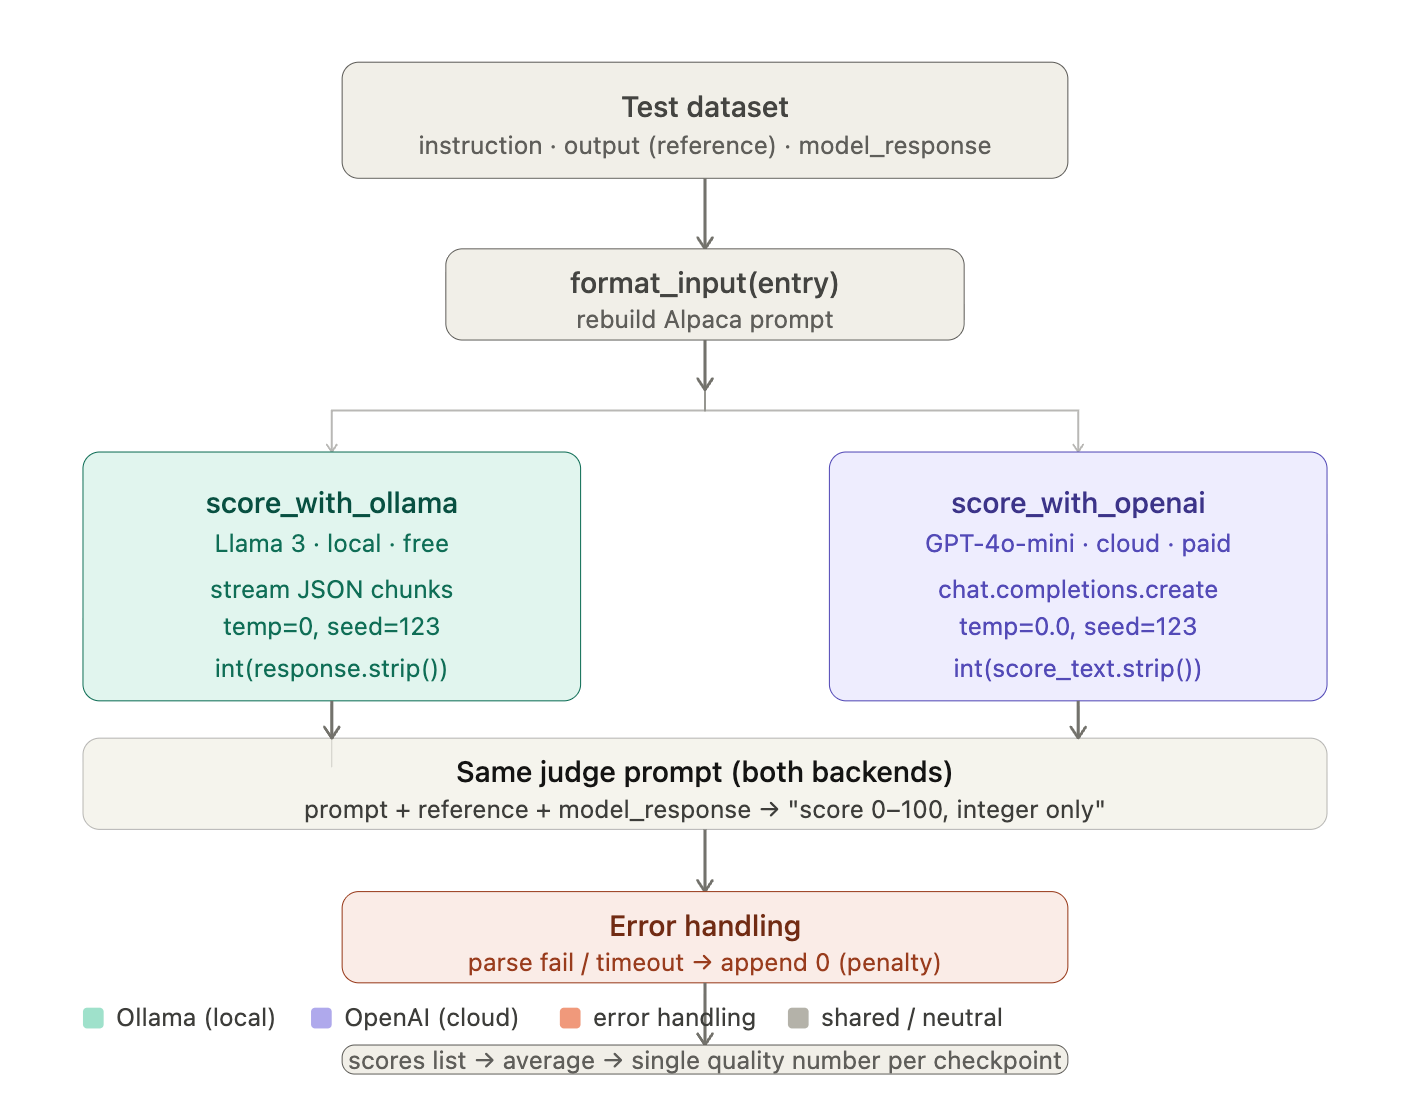

## What is being done

Uses a second LLM as a judge to score the fine-tuned model's responses on a
0–100 scale. Replaces brittle metrics like BLEU/ROUGE with a semantic quality
score. Two judge backends provided — local Ollama or cloud GPT-4o-mini.

---

## The judge prompt (same for both backends)

```
Given the input `{prompt}` and correct output `{reference}`,
score the model response `{model_response}` on a scale from 0 to 100.
Respond with the integer number only.
```

Three things are passed: the original prompt, the gold reference answer, and
the model's response. The reference is what anchors the score — without it
the judge has no baseline to compare against.

`temperature=0` + `seed=123` on both backends makes scores deterministic and
reproducible across runs so checkpoint comparisons are meaningful.

---

## Two backends — same prompt, different trade-offs

| Backend | Model | Cost | Strength |
|---|---|---|---|
| `score_with_ollama` | Llama 3 (local) | free | slower, weaker judge |
| `score_with_openai` | GPT-4o-mini | API cost | faster, stronger judge |

Practical tip: run Ollama first to cheaply filter bad responses, then use
GPT-4o-mini only for final evaluation.

---

## Error handling

Both functions wrap each scoring call in `try/except`. If the judge returns
something that can't be parsed as an integer, or the request times out,
`scores.append(0)` is used as a penalty rather than crashing the loop.

---

## What to remember

- LLM-as-judge = ask a stronger model to score your model's outputs 0–100.
- Judge needs all three: prompt + reference + model response.
- `temperature=0` is critical — without it scores vary run-to-run.
- Both backends use the identical prompt so scores are directly comparable.
- Failed parses default to 0 (penalty score, not ignored).
- `format_input()` is the same Alpaca helper from fine-tuning — judge sees the same context the model did.

In [ ]:
!pip install requests tqdm openai

"""
llm_evaluation_pipeline.py
============================
Evaluates the quality of a fine-tuned model's responses using the
"LLM-as-judge" pattern — instead of computing a metric like BLEU or ROUGE,
we ask a second LLM to score each response on a 0–100 scale.

Two judge backends are provided:
  • Local  — Ollama running Llama 3 on your own machine (free, slower)
  • Cloud  — OpenAI GPT-4o-mini via the API (costs money, faster, stronger)

Both use the same prompt and scoring scale so results are comparable.

Typical workflow:
  1. Run instruction fine-tuning → get test set with "model_response" field.
  2. Feed that test set into score_with_ollama() or score_with_openai().
  3. Average the scores to get a single quality number for the checkpoint.

Dependencies:
    pip install openai requests tqdm
"""

import json

import requests
from openai import OpenAI
from tqdm import tqdm


# ===========================================================================
# 1. Prompt formatting — Alpaca template
# ===========================================================================
# Identical to the helper used during fine-tuning (gpt2_instruction_finetuning.py).
# We reconstruct the same prompt the model saw during training so the judge
# evaluates the response in the correct context.
# ===========================================================================

def format_input(entry: dict) -> str:
    """
    Build the Alpaca-style instruction prompt for a single entry.

    Produces everything the model received as input (instruction + optional
    input section) but does NOT include the ### Response: section — that is
    what we are scoring.

    Args:
        entry: Dict with keys 'instruction' and optionally 'input'.

    Returns:
        Formatted prompt string.
    """
    instruction_text = (
        "Below is an instruction that describes a task. "
        "Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )
    input_text = f"\n\n### Input:\n{entry['input']}" if entry.get("input") else ""
    return instruction_text + input_text


# ===========================================================================
# 2. Local evaluation — Ollama / Llama 3
# ===========================================================================
# Uses a locally running Ollama instance as the judge.
#
# Judge prompt design:
#   We give the judge three things:
#     (a) the original prompt  — so it knows what was asked
#     (b) the reference output — the "gold" answer from the dataset
#     (c) the model response   — what our fine-tuned model actually said
#   The judge is instructed to respond with a single integer (0–100).
#
# Determinism:
#   temperature=0 and seed=123 make the judge's scores reproducible across
#   runs.  Without this, the same response could receive different scores
#   on different runs, making comparisons unreliable.
#
# Error handling:
#   If the judge returns something that can't be parsed as an int (e.g. it
#   adds commentary), or if the request times out, we append 0 as a penalty
#   score rather than crashing the whole evaluation loop.
#
# Requirements: `ollama serve` must be running before calling this.
# ===========================================================================

def score_with_ollama(
    json_data: list[dict],
    target_key: str = "model_response",
    url: str = "http://localhost:11434/api/chat",
) -> list[int]:
    """
    Score each entry in `json_data` using a local Ollama judge.

    Args:
        json_data:   List of dicts, each containing 'instruction', 'input',
                     'output' (reference), and the key named by `target_key`.
        target_key:  The field holding the model's response to evaluate.
                     Default: "model_response".
        url:         Ollama chat endpoint.

    Returns:
        List of integer scores (0–100), one per entry.
        Failed parses default to 0.
    """
    scores = []
    print("Starting local evaluation via Ollama...")

    for entry in tqdm(json_data):
        # Build the judge prompt: context + reference + response to score
        prompt = (
            f"Given the input `{format_input(entry)}` "
            f"and correct output `{entry['output']}`, "
            f"score the model response `{entry[target_key]}` "
            f"on a scale from 0 to 100, where 100 is the best score. "
            f"Respond with the integer number only."
        )

        payload = {
            "model": "llama3",
            "messages": [{"role": "user", "content": prompt}],
            "options": {
                "seed": 123,
                "temperature": 0,   # deterministic output — must produce just a number
            },
        }

        try:
            response_data = ""
            with requests.post(url, json=payload, stream=True, timeout=30) as r:
                r.raise_for_status()
                # Ollama streams response as newline-delimited JSON chunks
                for line in r.iter_lines(decode_unicode=True):
                    if line:
                        chunk = json.loads(line)
                        if "message" in chunk:
                            response_data += chunk["message"]["content"]

            # Strip whitespace and cast to int — judge should return "85" not "Score: 85"
            scores.append(int(response_data.strip()))

        except Exception as e:
            # Catch parse errors, network timeouts, and HTTP errors gracefully
            print(f"Failed to score entry: {e}")
            scores.append(0)   # penalty score for failed evaluations

    return scores


# ===========================================================================
# 3. Cloud evaluation — OpenAI GPT-4o-mini
# ===========================================================================
# Same judge prompt as the Ollama version — the only difference is the
# API client and model name.  This lets you run both and compare scores
# to check whether the local judge and the cloud judge agree.
#
# temperature=0 + seed=123 serve the same purpose as in the Ollama version:
# deterministic, reproducible scores.
#
# Cost note: each call sends the full prompt (instruction + reference + response)
# to the OpenAI API.  For large test sets this adds up — run Ollama first to
# filter obviously bad responses, then use GPT-4o-mini for final evaluation.
# ===========================================================================

def score_with_openai(
    json_data: list[dict],
    target_key: str = "model_response",
    api_key: str = "YOUR_API_KEY",
) -> list[int]:
    """
    Score each entry in `json_data` using GPT-4o-mini as the judge.

    Args:
        json_data:   List of dicts with the same structure as score_with_ollama.
        target_key:  Field holding the model response to evaluate.
        api_key:     OpenAI API key (or set via OPENAI_API_KEY env var).

    Returns:
        List of integer scores (0–100), one per entry.
        Failed parses default to 0.
    """
    client = OpenAI(api_key=api_key)
    scores = []
    print("Starting cloud evaluation via OpenAI...")

    for entry in tqdm(json_data):
        # Identical judge prompt to the Ollama version for apples-to-apples comparison
        prompt = (
            f"Given the input `{format_input(entry)}` "
            f"and correct output `{entry['output']}`, "
            f"score the model response `{entry[target_key]}` "
            f"on a scale from 0 to 100, where 100 is the best score. "
            f"Respond with the integer number only."
        )

        try:
            response = client.chat.completions.create(
                model="gpt-4o-mini",
                messages=[{"role": "user", "content": prompt}],
                temperature=0.0,   # deterministic
                seed=123,
            )
            score_text = response.choices[0].message.content
            scores.append(int(score_text.strip()))

        except Exception as e:
            print(f"Failed to score entry: {e}")
            scores.append(0)

    return scores


# ===========================================================================
# 4. Main execution
# ===========================================================================

if __name__ == "__main__":

    # -----------------------------------------------------------------------
    # Dummy test set — simulates the output of instruction fine-tuning
    # -----------------------------------------------------------------------
    # In practice, replace this with the JSON file produced after generation:
    #   with open("instruction-data-with-response.json") as f:
    #       test_dataset = json.load(f)
    #
    # Each entry must have:
    #   "instruction"    — the original task
    #   "input"          — optional context (can be empty string)
    #   "output"         — the reference / gold answer
    #   "model_response" — what the fine-tuned model generated
    test_dataset = [
        {
            "instruction": "Calculate the hypotenuse of a right triangle with legs of 6 cm and 8 cm.",
            "input": "",
            "output": "The hypotenuse of the triangle is 10 cm.",
            "model_response": "The hypotenuse of the triangle is 10 cm.",  # perfect — expect ~100
        },
        {
            "instruction": "What is the capital of France?",
            "input": "",
            "output": "Paris.",
            "model_response": "I think it is London.",  # wrong — expect ~0
        },
    ]

    # -----------------------------------------------------------------------
    # Option A: Local evaluation with Ollama
    # -----------------------------------------------------------------------
    # Runs entirely on your machine — no API cost.
    # Requires: `ollama serve` running in a separate terminal.
    # Uncomment to use:
    #
    # local_scores = score_with_ollama(test_dataset)
    # print(f"\nLocal Ollama scores: {local_scores}")
    # print(f"Average: {sum(local_scores) / len(local_scores):.2f}")

    # -----------------------------------------------------------------------
    # Option B: Cloud evaluation with GPT-4o-mini
    # -----------------------------------------------------------------------
    # Stronger judge, costs money per call.
    # The same prompt is used so scores are directly comparable to Option A.
    # Uncomment to use:
    #
    # openai_scores = score_with_openai(test_dataset, api_key="sk-YOUR-KEY")
    # print(f"\nOpenAI scores: {openai_scores}")
    # print(f"Average: {sum(openai_scores) / len(openai_scores):.2f}")

# DPO Fine-Tuning

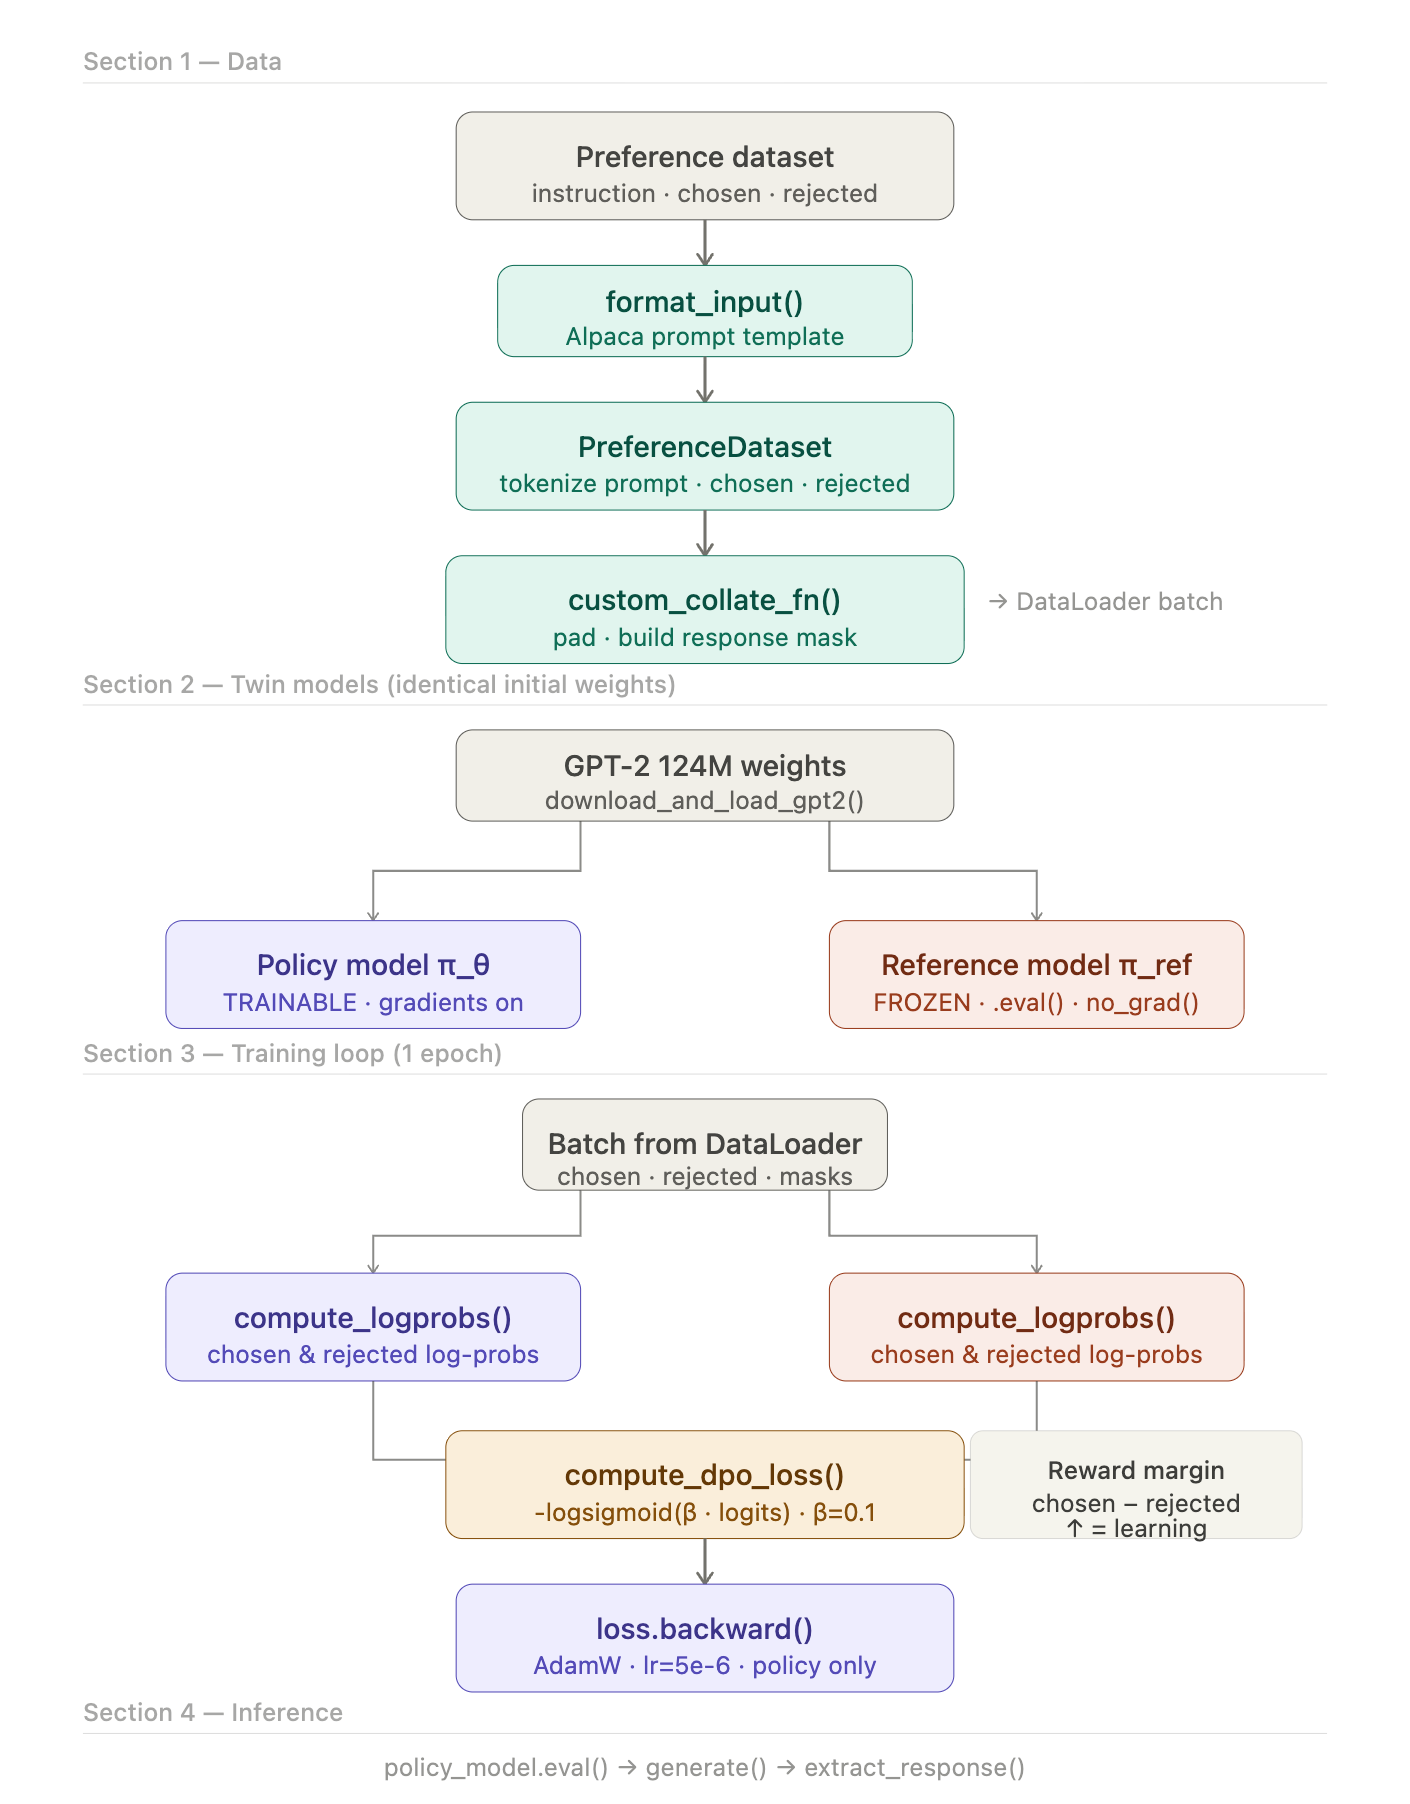

## What is DPO?
A fine-tuning method that teaches a model human preferences using **(chosen, rejected)** response pairs — no separate reward model needed.

**Loss formula:**
```
L = -log σ( β * [(log π_policy(chosen) - log π_ref(chosen)) - (log π_policy(rejected) - log π_ref(rejected))] )
```
In plain English: push the policy to be *relatively more confident* on chosen responses and *relatively less confident* on rejected ones, compared to a frozen reference model.

---

## The 5 Moving Parts

### 1. Data — `format_input` + `PreferenceDataset`
- Formats each entry into the **Alpaca template** (`### Instruction / ### Input / ### Response`)
- Stores three tokenized sequences per example: `prompt`, `chosen` (full), `rejected` (full)
- Full sequences are stored because the model needs full context to produce accurate logits

### 2. Collation — `custom_collate_fn`
- Pads all sequences to the same length (right-pad with EOS token `50256`)
- Builds a **boolean mask** that is `True` only for response tokens — masking out both the prompt prefix and padding so the loss isn't polluted by either

### 3. Log-prob scoring — `compute_logprobs`
- Shifts logits/labels by 1 (standard next-token prediction alignment)
- Uses `torch.gather` to extract the log-prob at each *actual* token position
- Applies the mask, then **averages over response tokens only** (length-normalised)

### 4. DPO loss — `compute_dpo_loss`
- Computes `(policy_chosen − policy_rejected) − (ref_chosen − ref_rejected)` → the "logits"
- Passes through `-logsigmoid(β × logits)` — minimised when the policy prefers chosen over rejected *more than* the reference does
- Also returns `chosen_reward` and `rejected_reward` (detached) purely for monitoring — the **reward margin** (chosen − rejected) should grow during training

### 5. Training loop
- Runs **two forward passes** per batch: policy model (with gradients) + reference model (inside `torch.no_grad()`)
- Only the **policy model** is passed to the optimizer — reference weights never change
- **1 epoch only** — DPO is prone to reward hacking / collapse with more

---

## Key Design Decisions to Remember
| Decision | Why |
|---|---|
| Two identical models | Reference anchors the policy; prevents degenerate drift |
| Mask the prompt | Preference signal lives in the response, not the instruction |
| β = 0.1 | Low value = conservative update, stays close to reference |
| 1 epoch | More epochs → reward hacking / loss instability |
| `eval()` on reference | Disables dropout; ensures deterministic log-probs |

In [ ]:
!pip install tiktoken torch matplotlib
!wget https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch07/01_main-chapter-code/previous_chapters.py
!wget https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch07/01_main-chapter-code/gpt_download.py
!wget https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch07/04_preference-tuning-with-dpo/instruction-data-with-preference.json

"""
=============================================================================
Direct Preference Optimization (DPO) Fine-Tuning — Fully Annotated
=============================================================================

WHAT IS DPO?
DPO is a fine-tuning technique that aligns a language model with human
preferences WITHOUT needing a separate reward model (unlike traditional RLHF).

The key idea: given pairs of (chosen, rejected) responses to the same prompt,
we nudge the *policy model* to assign higher probability to chosen responses
relative to a frozen *reference model*.

The DPO Loss:
  L = -log σ( β * [(log π_θ(chosen) - log π_ref(chosen))
                  - (log π_θ(rejected) - log π_ref(rejected))] )

  Where:
    π_θ   = policy model (the one we're training)
    π_ref = reference model (frozen copy of the initial weights)
    β     = temperature controlling how aggressively we deviate from the ref
    σ     = sigmoid function

HOW TO READ THIS FILE:
  Section 1 — Dataset & Formatting:     How preference pairs are structured
  Section 2 — Log-Probability Math:     The core DPO computation
  Section 3 — Model Setup:              Loading twin GPT-2 models
  Section 4 — Training Loop:            The actual DPO update step
  Section 5 — Inference:                Generating from the trained model
=============================================================================
"""

import json
import torch
import torch.nn.functional as F
import tiktoken
from torch.utils.data import Dataset, DataLoader
from gpt_download import download_and_load_gpt2
from previous_chapters import GPTModel, load_weights_into_gpt


# =============================================================================
# SECTION 1: Dataset & Formatting
# =============================================================================
# DPO training data is a list of dicts, each with:
#   - "instruction": the task description shown to the model
#   - "input":       optional extra context for the task
#   - "chosen":      the *preferred* response (human-approved)
#   - "rejected":    the *dispreferred* response (human-disapproved)
#
# We use the Alpaca-style prompt template so the format at inference time
# matches exactly what the model saw during fine-tuning.
# =============================================================================

def format_input(entry):
    """
    Converts a data dict into the Alpaca instruction-following prompt template.

    The template has two variants:
      - WITH extra input:    "Below is an instruction...  ### Input: <input>"
      - WITHOUT extra input: just the instruction block (empty string fallback)

    Note: The "### Response:" suffix is NOT added here — it's appended separately
    so that the prompt boundary (where the response starts) is clearly defined.
    """
    instruction_block = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    # Only append the input block if the entry actually has non-empty input
    input_block = (
        f"\n\n### Input:\n{entry['input']}"
        if entry.get("input")   # Evaluates to False for "" or missing key
        else ""
    )

    return instruction_block + input_block


class PreferenceDataset(Dataset):
    """
    Tokenizes and stores (prompt, chosen, rejected) triples for DPO training.

    Each example stores:
      - prompt:   token IDs for the instruction (without any response)
      - chosen:   token IDs for the FULL sequence (prompt + chosen response)
      - rejected: token IDs for the FULL sequence (prompt + rejected response)

    We store the full sequences (not just the response tokens) because the
    model needs the full context to compute accurate logits. The prompt portion
    is later *masked out* in `custom_collate_fn` so that loss is only computed
    over the actual response tokens.
    """

    def __init__(self, data, tokenizer):
        self.data = data
        self.encoded_texts = []

        for entry in data:
            prompt = format_input(entry)

            # Full sequences: prompt + "### Response:" header + actual text
            chosen_full   = tokenizer.encode(f"{prompt}\n\n### Response:\n{entry['chosen']}")
            rejected_full = tokenizer.encode(f"{prompt}\n\n### Response:\n{entry['rejected']}")

            self.encoded_texts.append({
                "prompt":   tokenizer.encode(prompt),   # Used to compute the mask boundary
                "chosen":   chosen_full,
                "rejected": rejected_full,
            })

    def __getitem__(self, index):
        return self.encoded_texts[index]

    def __len__(self):
        return len(self.data)


def custom_collate_fn(batch, pad_token_id=50256, device="cpu"):
    """
    Pads sequences in a batch to the same length and builds boolean masks.

    WHY PADDING?
      Sequences in the batch have different lengths. PyTorch requires all
      tensors in a batch to have the same shape, so we pad shorter sequences
      to match the longest one using the EOS/pad token (id=50256 for GPT-2).

    WHY MASKING?
      We only want to compute the DPO loss over the *response* tokens.
      Tokens from two regions should be ignored:
        1. Prompt tokens:   the instruction is the same for chosen and rejected,
                            so it doesn't carry preference signal.
        2. Padding tokens:  these are not real data and would corrupt the loss.

    The returned mask is True only for the response tokens we care about.

    Args:
        batch:        List of dicts from PreferenceDataset.__getitem__
        pad_token_id: Token ID used for right-padding (GPT-2 EOS = 50256)
        device:       Target device for the returned tensors
    """
    batch_data = {
        "chosen":        [],
        "rejected":      [],
        "chosen_mask":   [],
        "rejected_mask": [],
    }

    # Find the longest sequence across both chosen and rejected in the batch.
    # +1 accounts for the extra token shift used in next-token prediction.
    max_len = max(
        max(len(item["chosen"]) + 1, len(item["rejected"]) + 1)
        for item in batch
    )

    for item in batch:
        prompt_len = len(item["prompt"])

        for key in ["chosen", "rejected"]:
            sequence = item[key]

            # Pad the sequence to max_len with the pad token
            padded = sequence + [pad_token_id] * (max_len - len(sequence))

            # Start with all True (everything "counts")
            mask = torch.ones(len(padded)).bool()

            # Mask out the padding region (beyond the actual sequence length)
            mask[len(sequence):] = False

            # Mask out the prompt region.
            # +2 accounts for the "\n\n" separator before "### Response:"
            mask[:prompt_len + 2] = False

            batch_data[key].append(torch.tensor(padded))
            batch_data[f"{key}_mask"].append(mask)

    # Stack list of 1D tensors → 2D batch tensors, then move to device
    for key in batch_data:
        batch_data[key] = torch.stack(batch_data[key]).to(device)

    return batch_data


# =============================================================================
# SECTION 2: DPO Log-Probability & Loss Math
# =============================================================================
# The DPO loss requires computing how likely the model thinks each response is.
# Specifically, we need the average log-probability of the response tokens
# (not including the prompt or padding).
#
# Log-probability intuition:
#   If the model predicts "cat" at position t with 80% confidence,
#   the log-prob for that token is log(0.80) ≈ -0.22.
#   Lower magnitude = model is more confident = the sequence is more likely.
# =============================================================================

def compute_logprobs(logits, labels, selection_mask):
    """
    Computes the mean log-probability of the response tokens for each sequence.

    NEXT-TOKEN PREDICTION ALIGNMENT:
      Language models output logits[t] predicting token t+1.
      So to compare prediction vs. actual token, we shift:
        - logits[:, :-1, :] → predictions for positions 0..T-2
        - labels[:, 1:]     → actual tokens at positions 1..T-1

    HOW torch.gather WORKS HERE:
      log_probs has shape [batch, seq_len, vocab_size].
      labels.unsqueeze(-1) has shape [batch, seq_len, 1] — one index per position.
      torch.gather picks exactly the log-prob at the actual label token,
      giving us shape [batch, seq_len, 1], then .squeeze(-1) → [batch, seq_len].

    AVERAGING OVER RESPONSE TOKENS ONLY:
      We multiply by the mask (0 for prompt/padding, 1 for response) and divide
      by the count of True mask values. This gives a length-normalized score so
      that shorter and longer responses are compared fairly.

    Args:
        logits:         Raw model output — shape [batch, seq_len, vocab_size]
        labels:         Token ID sequence  — shape [batch, seq_len]
        selection_mask: Boolean mask        — shape [batch, seq_len]
                        True only for response tokens we want to score

    Returns:
        Tensor of shape [batch] — average log-prob per sequence
    """
    # Shift labels and logits to align predictions with targets
    labels = labels[:, 1:].clone()          # actual tokens (shifted right by 1)
    logits = logits[:, :-1, :]             # predictions (shifted left by 1)

    # Convert raw logits to log-probabilities over the vocabulary
    log_probs = F.log_softmax(logits, dim=-1)

    # For each position, extract the log-prob of the token that actually appeared
    selected_log_probs = torch.gather(
        input=log_probs,
        dim=-1,
        index=labels.unsqueeze(-1)
    ).squeeze(-1)                           # Shape: [batch, seq_len - 1]

    # Apply mask: zero out positions we don't want to score
    mask = selection_mask[:, 1:].clone()    # Shift mask to match the shift above
    selected_log_probs = selected_log_probs * mask

    # Average over response token positions (not over total length)
    return selected_log_probs.sum(-1) / mask.sum(-1)  # Shape: [batch]


def compute_dpo_loss(
    policy_chosen_logprobs,
    policy_rejected_logprobs,
    ref_chosen_logprobs,
    ref_rejected_logprobs,
    beta=0.1
):
    """
    Computes the DPO loss for a batch of (chosen, rejected) pairs.

    INTUITION:
      The policy model starts identical to the reference model. During training,
      we want it to become *relatively more confident* about chosen responses
      than the reference, and *relatively less confident* about rejected ones.

      We measure this as a ratio:
        Chosen shift   = log π_θ(chosen)   - log π_ref(chosen)   ← should be > 0
        Rejected shift = log π_θ(rejected) - log π_ref(rejected) ← should be < 0

      The DPO logits = (chosen shift) - (rejected shift) should be large and positive.
      Passing through logsigmoid gives a loss that is minimized when this holds.

    BETA (β):
      Controls how far the policy can deviate from the reference.
        - Small β (e.g., 0.1): gentle update, stays close to the reference
        - Large β:             aggressive update, bigger preference signal

    REWARD TRACKING (for monitoring, not training):
      We compute scalar "reward" values to track training health:
        chosen_reward   > 0 means policy got more confident on chosen than ref
        rejected_reward < 0 means policy got less confident on rejected than ref
        margin = chosen_reward - rejected_reward should grow during training

    Args:
        policy_chosen_logprobs:   avg log-prob of chosen under policy   [batch]
        policy_rejected_logprobs: avg log-prob of rejected under policy [batch]
        ref_chosen_logprobs:      avg log-prob of chosen under reference [batch]
        ref_rejected_logprobs:    avg log-prob of rejected under reference [batch]
        beta:                     KL penalty coefficient (default 0.1)

    Returns:
        loss:             scalar — mean DPO loss over the batch
        chosen_rewards:   scalar — mean chosen reward (monitoring only)
        rejected_rewards: scalar — mean rejected reward (monitoring only)
    """
    # Compute how much the policy shifted relative to the reference
    policy_ratio = policy_chosen_logprobs - policy_rejected_logprobs
    ref_ratio    = ref_chosen_logprobs    - ref_rejected_logprobs

    # The DPO objective: maximize the gap between chosen and rejected shifts
    logits = policy_ratio - ref_ratio                   # Should be large & positive

    # -logsigmoid is the DPO loss — minimized when logits >> 0
    losses = -F.logsigmoid(beta * logits)

    # Detach rewards from the computation graph — used only for logging
    chosen_rewards   = (policy_chosen_logprobs   - ref_chosen_logprobs).detach()
    rejected_rewards = (policy_rejected_logprobs - ref_rejected_logprobs).detach()

    return losses.mean(), chosen_rewards.mean(), rejected_rewards.mean()


# =============================================================================
# SECTION 3: Model & Data Setup
# =============================================================================
# DPO requires TWO copies of the same base model:
#
#   policy_model:    The model we are actively training (gradients ON).
#   reference_model: A frozen snapshot of the starting weights (gradients OFF).
#
# The reference model acts as an "anchor" — it prevents the policy from
# collapsing to degenerate outputs by penalizing large deviations from where
# we started. This is the KL divergence term in the DPO objective.
#
# Both models start with IDENTICAL weights (pre-trained GPT-2 124M).
# Over training, only the policy model's weights change.
# =============================================================================

device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = tiktoken.get_encoding("gpt2")

# Load the preference dataset (instruction, chosen, rejected triples)
with open("instruction-data-with-preference.json", "r") as f:
    data = json.load(f)[:200]   # Use a 200-example subset for fast experimentation

train_loader = DataLoader(
    PreferenceDataset(data, tokenizer),
    batch_size=2,
    collate_fn=lambda b: custom_collate_fn(b, device=device),
)

# GPT-2 124M architecture hyperparameters
BASE_CONFIG = {
    "vocab_size":      50257,   # GPT-2 tokenizer vocabulary size
    "context_length":  1024,    # Maximum sequence length the model can process
    "drop_rate":       0.0,     # No dropout during fine-tuning
    "qkv_bias":        True,    # Include bias in Q/K/V projection layers
    "emb_dim":         768,     # Hidden dimension of the model
    "n_layers":        12,      # Number of transformer blocks
    "n_heads":         12,      # Number of attention heads per block
}

# Download pre-trained GPT-2 weights from OpenAI
settings, params = download_and_load_gpt2(model_size="124M", models_dir="gpt2")

# --- Policy Model (trainable) ---
policy_model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(policy_model, params)
policy_model.to(device)         # Move AFTER loading weights (avoids double allocation)

# --- Reference Model (frozen) ---
reference_model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(reference_model, params)
reference_model.to(device)
reference_model.eval()          # .eval() disables dropout and signals no gradient updates

# Both models now hold identical weights. Only the policy model will be updated.


# =============================================================================
# SECTION 4: The DPO Training Loop
# =============================================================================
# Key differences from standard supervised fine-tuning (SFT):
#   - We run BOTH models on every batch (policy + reference)
#   - The reference model runs inside torch.no_grad() — no gradient tracking
#   - Only the policy model's parameters are passed to the optimizer
#   - We train for only 1 epoch because DPO is prone to reward hacking /
#     mode collapse if run too long
# =============================================================================

# Only the policy model's weights are updated by the optimizer.
# Even though reference_model has the same architecture, its parameters
# are NOT passed here, so they will never receive gradient updates.
optimizer = torch.optim.AdamW(policy_model.parameters(), lr=5e-6)

print("Starting DPO Finetuning...")

# 1 epoch is the standard practice for DPO — more epochs risk the policy
# drifting so far from the reference that the loss signal becomes unreliable.
for epoch in range(1):
    policy_model.train()

    for step, batch in enumerate(train_loader):
        optimizer.zero_grad()

        # ── Step 1: Policy Model Forward Pass ─────────────────────────────
        # Compute the policy model's log-prob for chosen and rejected sequences.
        # This IS tracked by autograd — we need gradients to update the weights.
        policy_chosen   = compute_logprobs(
            policy_model(batch["chosen"]),
            batch["chosen"],
            batch["chosen_mask"]
        )
        policy_rejected = compute_logprobs(
            policy_model(batch["rejected"]),
            batch["rejected"],
            batch["rejected_mask"]
        )

        # ── Step 2: Reference Model Forward Pass ──────────────────────────
        # Compute the reference model's log-probs. These are used in the loss
        # formula but should NOT flow gradients back to anyone (frozen model).
        with torch.no_grad():
            ref_chosen   = compute_logprobs(
                reference_model(batch["chosen"]),
                batch["chosen"],
                batch["chosen_mask"]
            )
            ref_rejected = compute_logprobs(
                reference_model(batch["rejected"]),
                batch["rejected"],
                batch["rejected_mask"]
            )

        # ── Step 3: Compute DPO Loss and Update ───────────────────────────
        loss, chosen_reward, rejected_reward = compute_dpo_loss(
            policy_chosen, policy_rejected,
            ref_chosen,    ref_rejected,
            beta=0.1       # Low beta = conservative deviation from reference
        )
        loss.backward()     # Compute gradients for the policy model only
        optimizer.step()    # Update policy model weights

        # ── Logging ───────────────────────────────────────────────────────
        # Reward margin is the key health metric:
        #   > 0 and growing → model is learning the preference signal
        #   ≈ 0 or shrinking → training may be stalled or collapsing
        if step % 10 == 0:
            margin = chosen_reward - rejected_reward
            print(f"Step {step:03d} | Loss: {loss.item():.4f} | Reward Margin: {margin:.4f}")

print("DPO Finetuning Complete!")


# =============================================================================
# SECTION 5: Generation / Inference
# =============================================================================
# After training, we test the policy model on a brand-new prompt it never
# saw during fine-tuning.
#
# The generation pipeline:
#   text prompt → tokenize → generate token IDs → decode → strip prompt prefix
# =============================================================================

from previous_chapters import generate


def extract_response(response_text, input_prompt):
    """
    Strips the prompt template prefix from the model's full output,
    returning only the newly generated response text.

    The model generates prompt + response as one continuous string.
    We slice off the known prompt prefix and clean the "### Response:" marker.

    Args:
        response_text: Full decoded string including prompt + response
        input_prompt:  The original prompt string used as model input

    Returns:
        Just the model's response as a clean string
    """
    return response_text[len(input_prompt):].replace("### Response:", "").strip()


# A fresh instruction the model has never seen — good for sanity-checking alignment
test_entry = {
    "instruction": "Explain the concept of Direct Preference Optimization (DPO) in one simple sentence.",
    "input": ""
}

# Format using the same Alpaca template used during training.
# We append "### Response:\n" to prime the model to begin its answer.
formatted_prompt = format_input(test_entry) + "\n\n### Response:\n"

# Tokenize the prompt and add a batch dimension: [seq_len] → [1, seq_len]
input_tokens  = tokenizer.encode(formatted_prompt)
token_tensor  = torch.tensor(input_tokens).unsqueeze(0).to(device)

print("Thinking...\n" + "=" * 40)

# Switch to eval mode: disables dropout for deterministic, stable generation
policy_model.eval()

with torch.no_grad():   # No gradient tracking needed for inference
    generated_token_ids = generate(
        model=policy_model,
        idx=token_tensor,
        max_new_tokens=150,             # Cap output length at 150 new tokens
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256                    # Stop generation at <|endoftext|> token
    )

# Decode the full generated sequence from token IDs back to a string
generated_text = tokenizer.decode(generated_token_ids.squeeze(0).tolist())

# Isolate just the model's answer (remove prompt prefix)
final_answer = extract_response(generated_text, formatted_prompt)

print(f"Instruction: {test_entry['instruction']}")
print(f"Model Answer:\n{final_answer}")

--2026-03-23 04:14:33--  https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch07/01_main-chapter-code/previous_chapters.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18236 (18K) [text/plain]
Saving to: ‘previous_chapters.py.3’

previous_chapters.p 100%[===================>]  17.81K  --.-KB/s    in 0s      

2026-03-23 04:14:33 (49.1 MB/s) - ‘previous_chapters.py.3’ saved [18236/18236]

--2026-03-23 04:14:33--  https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch07/01_main-chapter-code/gpt_download.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP re